Saving superstore.csv to superstore (5).csv
FIRST 5 ROWS
       Order ID  Order Date       Ship Mode Customer ID    Customer Name  \
0  CA-2019-1001  01-01-2019    Second Class    CG-12520      Claire Gute   
1  CA-2019-1002  03-01-2019  Standard Class    DV-13045  Darrin Van Huff   
2  CA-2019-1003  05-01-2019     First Class    SO-20335   Sean O'Donnell   
3  CA-2019-1004  06-01-2019  Standard Class    BH-11710  Brosina Hoffman   
4  CA-2019-1005  08-01-2019    Second Class    AA-10480     Andrew Allen   

     Segment Country             City           State Region         Category  \
0   Consumer     USA        Henderson        Kentucky  South        Furniture   
1  Corporate     USA      Los Angeles      California   West  Office Supplies   
2   Consumer     USA  Fort Lauderdale         Florida  South        Furniture   
3   Consumer     USA      Los Angeles      California   West       Technology   
4   Consumer     USA          Concord  North Carolina  South  Office Supplies   


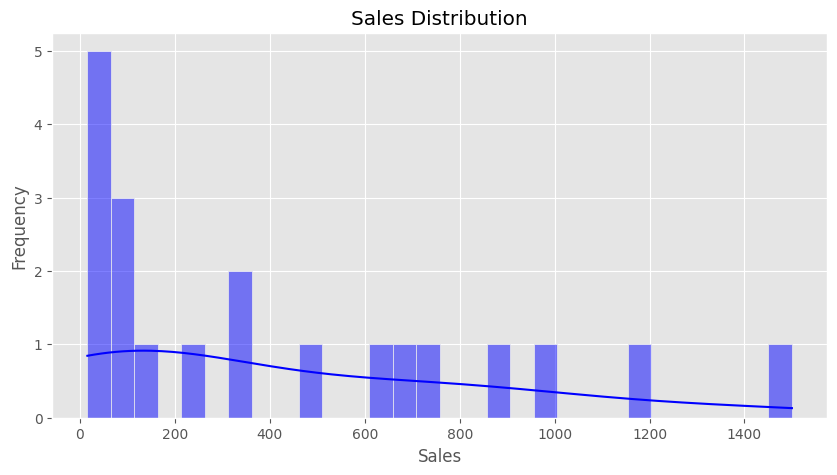

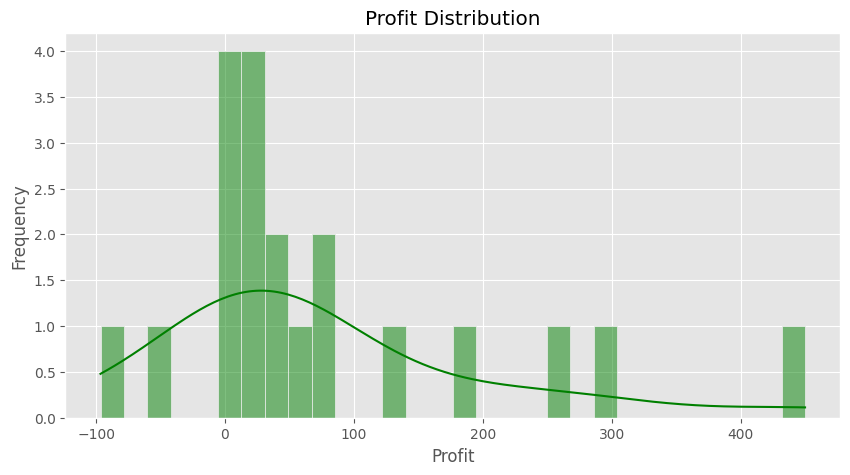

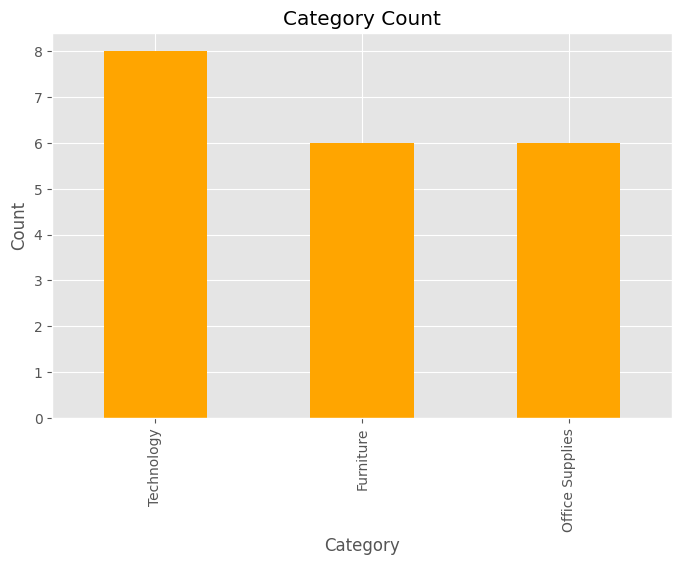

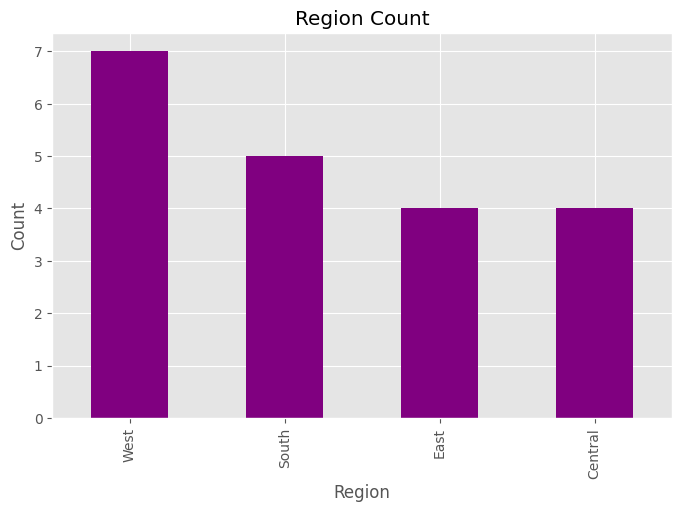

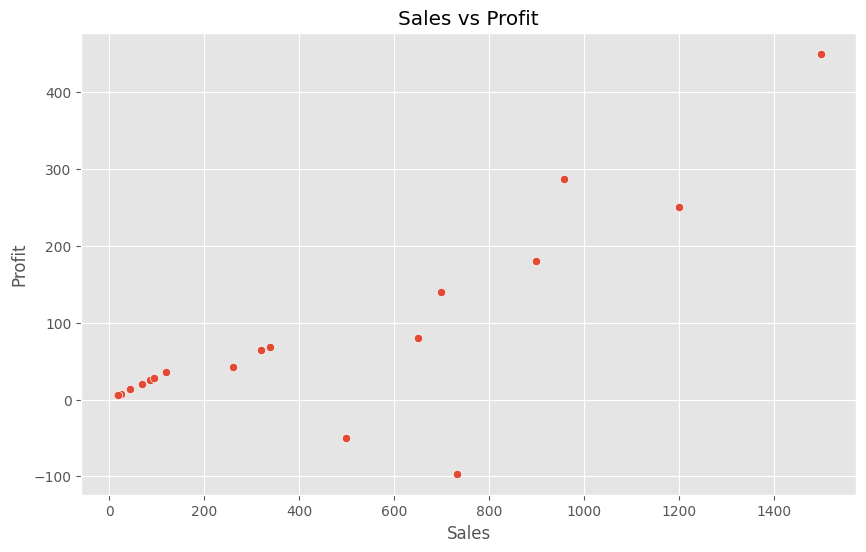

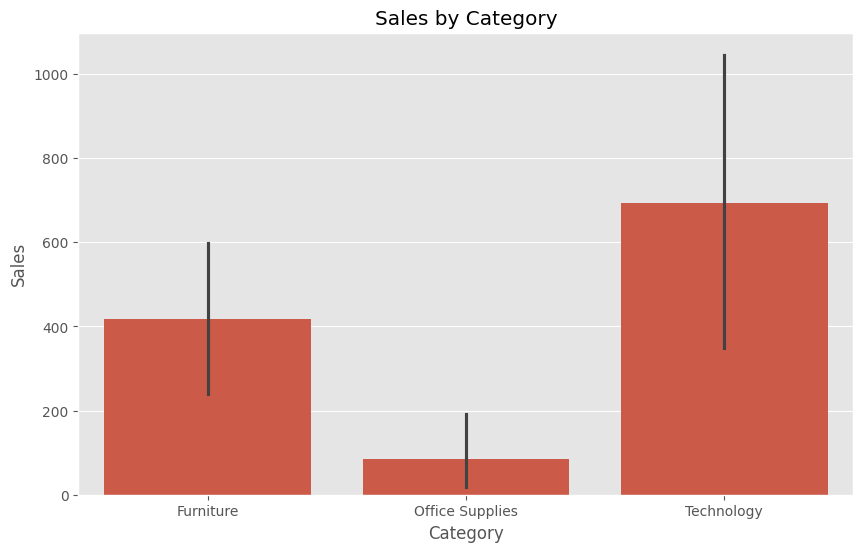

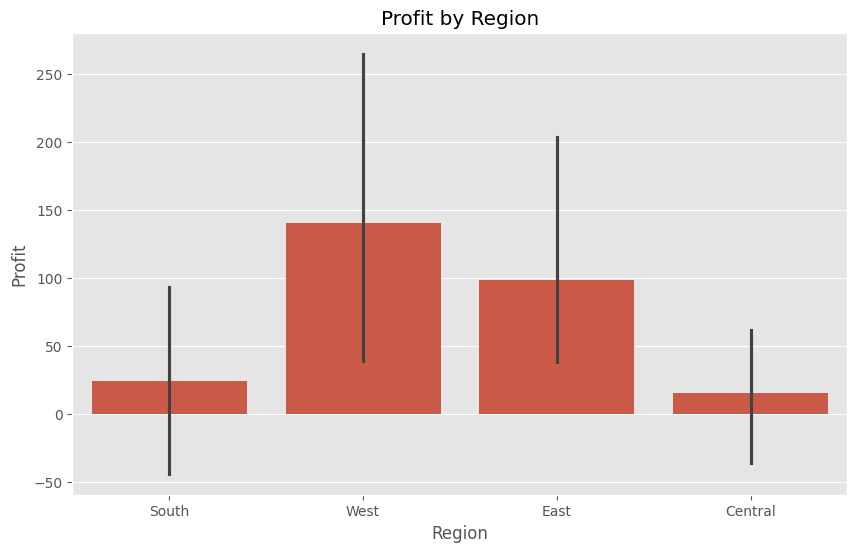

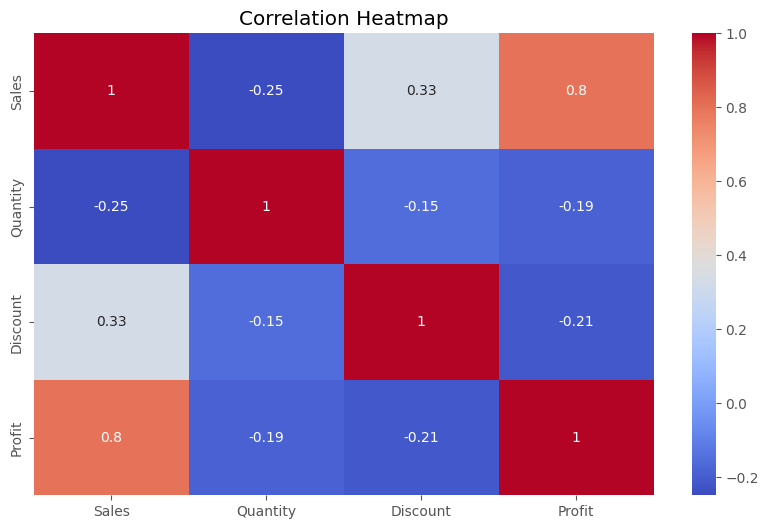

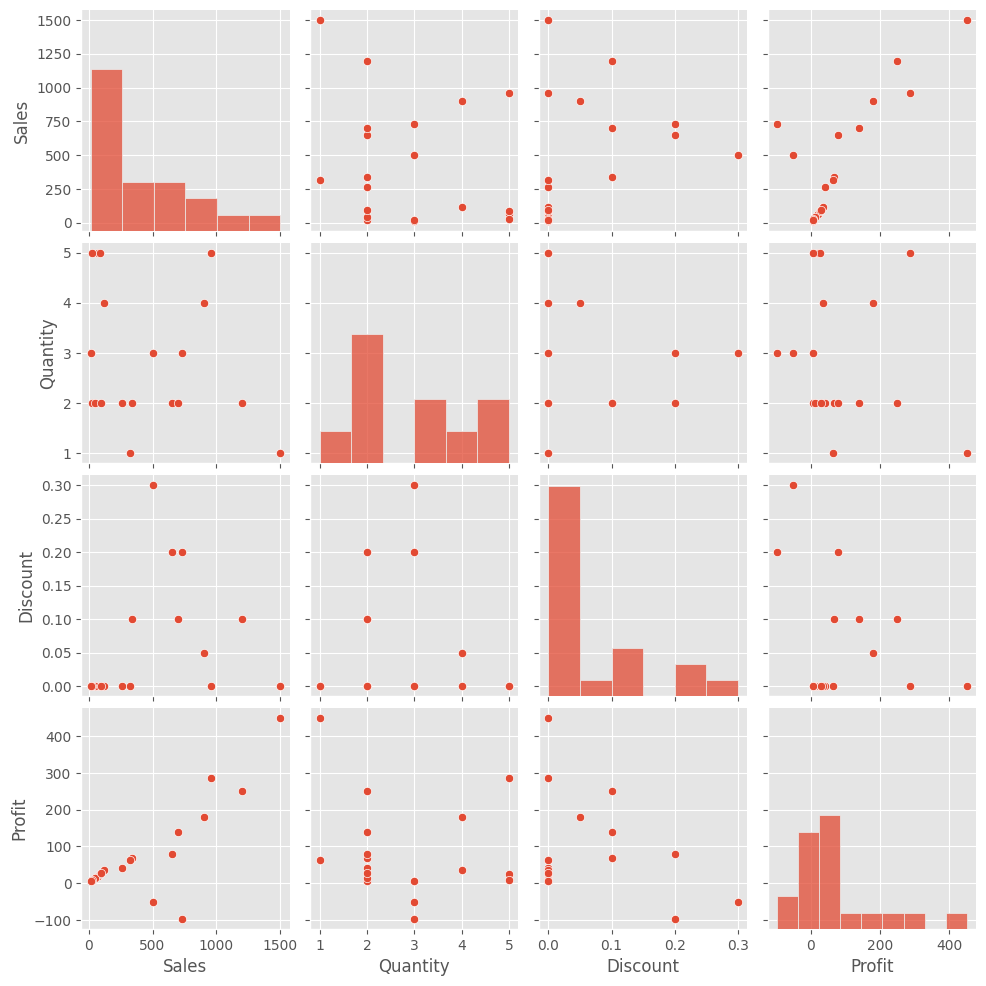


TOP 5 PRODUCTS BY SALES
           Product Name  Total_Sales
0    HP LaserJet Copier      1500.00
1  Dell Inspiron Laptop      1200.00
2       Apple iPhone 11       957.58
3    Samsung Galaxy S20       899.99
4     Office Star Chair       731.94

TOP CATEGORY BY PROFIT
          Category  Total_Profit
0       Technology       1392.41
1  Office Supplies        118.70
2        Furniture         52.87

REGION WITH HIGHEST SALES
    Region  Total_Sales
0     West      3579.93
1     East      1905.00
2    South      1811.27
3  Central      1260.50

AVERAGE DISCOUNT BY CATEGORY
          Category  Avg_Discount
0        Furniture      0.116667
1  Office Supplies      0.016667
2       Technology      0.031250

MONTHLY SALES TREND
   Month  Monthly_Sales
0      1         8123.7
1      2          433.0


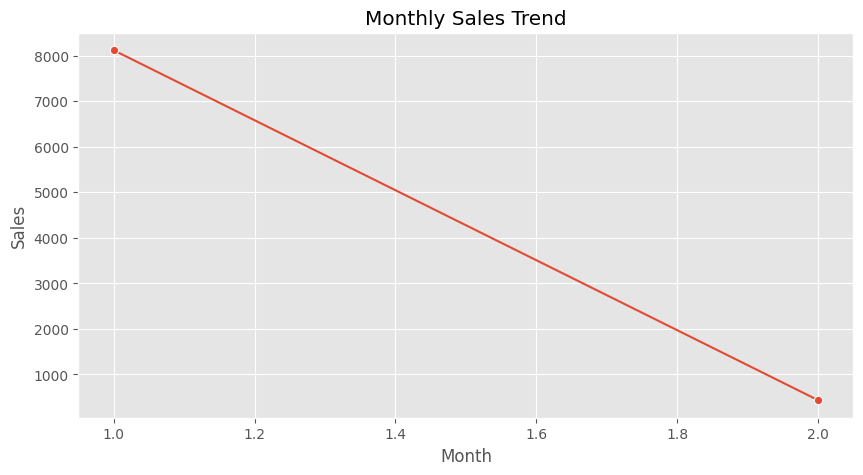


================ KPI REPORT ================
TOTAL SALES      : 8556.7
TOTAL PROFIT     : 1563.98
TOTAL ORDERS     : 20
AVERAGE SALES    : 427.83500000000004


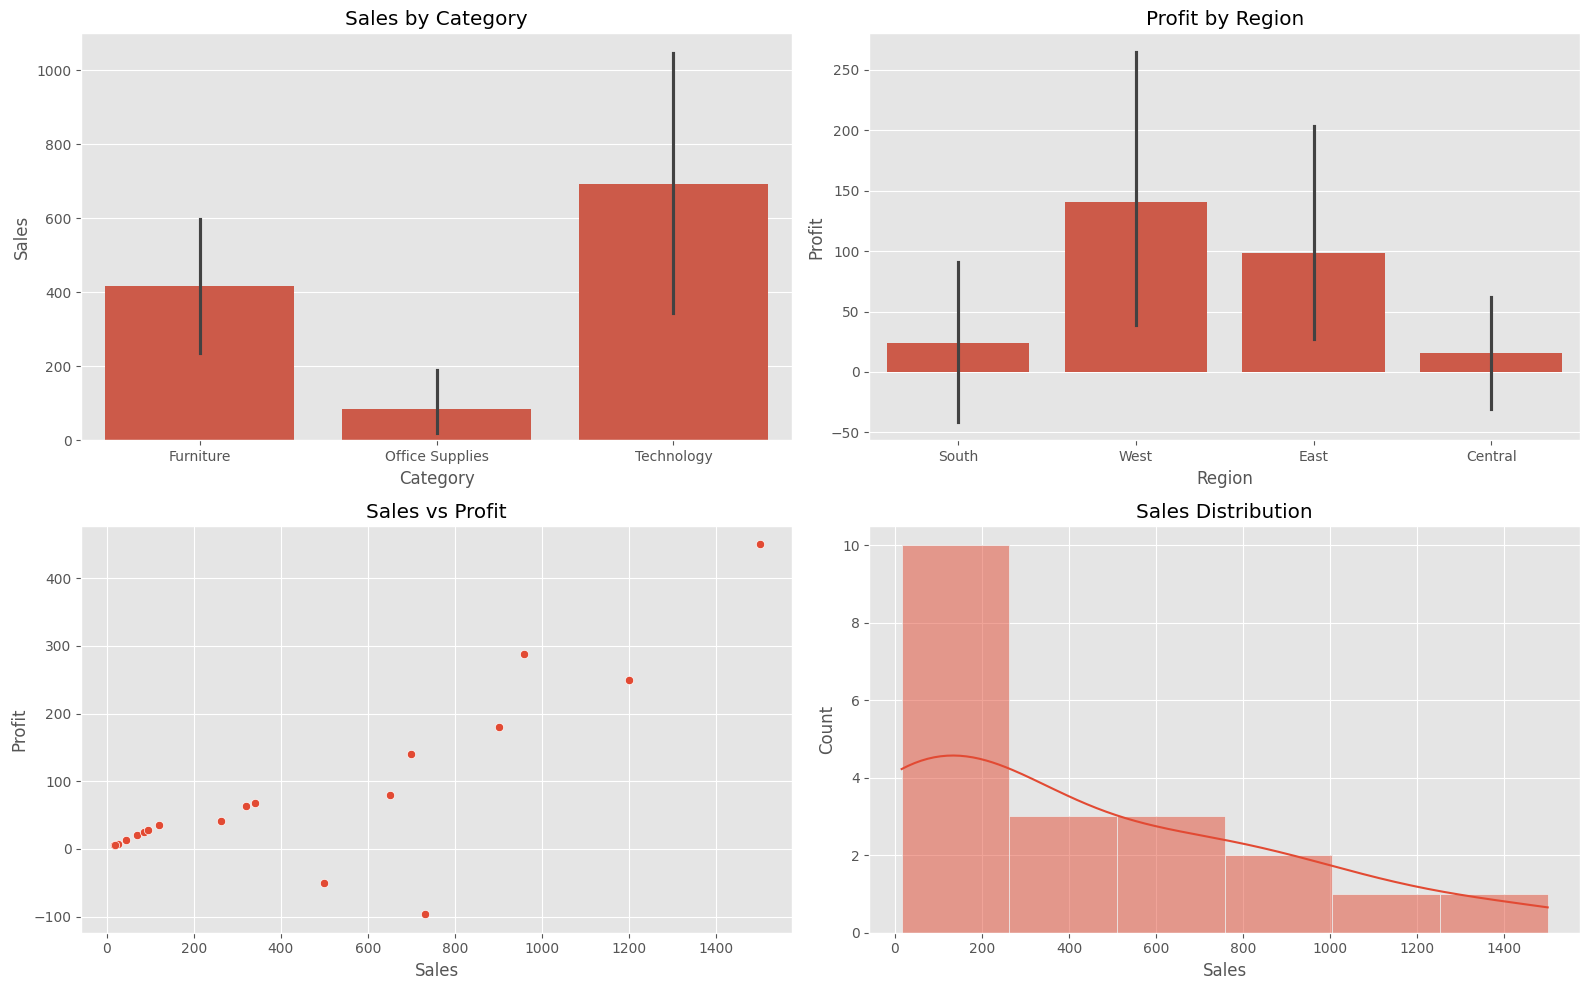


CLEANED DATA EXPORTED SUCCESSFULLY

SQL FILE SAVED

================ FINAL INSIGHTS ================

1. Identify which category generates highest sales.
2. Find the most profitable region.
3. Understand customer purchasing trends.
4. Analyze impact of discounts on profit.
5. Detect seasonal monthly sales trends.


EDA & BUSINESS INTELLIGENCE PROJECT COMPLETED


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandasql import sqldf

import plotly.express as px

plt.style.use('ggplot')
# STEP 3: UPLOAD DATASET
from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file
uploaded_filename = list(uploaded.keys())[0]

# STEP 4: LOAD DATASET
df = pd.read_csv(uploaded_filename)

# STEP 5: VIEW DATA

print("FIRST 5 ROWS")
print(df.head())

print("\nDATA INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# STEP 6: CHECK NULL VALUES

print("\nMISSING VALUES")
print(df.isnull().sum())

# STEP 7: CHECK DUPLICATES

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

# STEP 8: REMOVE DUPLICATES

df.drop_duplicates(inplace=True)

print("\nNEW SHAPE AFTER REMOVING DUPLICATES")
print(df.shape)

# UNIVARIATE ANALYSIS
# SALES DISTRIBUTION

plt.figure(figsize=(10,5))

sns.histplot(df['Sales'], bins=30, kde=True, color='blue')

plt.title('Sales Distribution')

plt.xlabel('Sales')

plt.ylabel('Frequency')

plt.show()

# PROFIT DISTRIBUTION

plt.figure(figsize=(10,5))

sns.histplot(df['Profit'], bins=30, kde=True, color='green')

plt.title('Profit Distribution')

plt.xlabel('Profit')

plt.ylabel('Frequency')

plt.show()

# CATEGORY COUNT

plt.figure(figsize=(8,5))

df['Category'].value_counts().plot(kind='bar', color='orange')

plt.title('Category Count')

plt.xlabel('Category')

plt.ylabel('Count')

plt.show()

# REGION COUNT

plt.figure(figsize=(8,5))

df['Region'].value_counts().plot(kind='bar', color='purple')

plt.title('Region Count')

plt.xlabel('Region')

plt.ylabel('Count')

plt.show()

# MULTIVARIATE ANALYSIS
# SALES VS PROFIT

plt.figure(figsize=(10,6))

sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title('Sales vs Profit')

plt.show()

# SALES BY CATEGORY

plt.figure(figsize=(10,6))

sns.barplot(x='Category', y='Sales', data=df)

plt.title('Sales by Category')

plt.show()

# PROFIT BY REGION

plt.figure(figsize=(10,6))

sns.barplot(x='Region', y='Profit', data=df)

plt.title('Profit by Region')

plt.show()

# CORRELATION HEATMAP


plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# PAIRPLOT

sns.pairplot(df)

plt.show()

# SQL ANALYSIS

# CREATE SQL FUNCTION

pysqldf = lambda q: sqldf(q, globals())

# BUSINESS QUESTION 1
# TOP 5 PRODUCTS BY SALES


query1 = """

SELECT
    "Product Name",
    SUM(Sales) AS Total_Sales
FROM df
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 5

"""

top_products = pysqldf(query1)

print("\nTOP 5 PRODUCTS BY SALES")
print(top_products)

# BUSINESS QUESTION 2
# TOP CATEGORY BY PROFIT

query2 = """

SELECT
    Category,
    SUM(Profit) AS Total_Profit
FROM df
GROUP BY Category
ORDER BY Total_Profit DESC

"""

top_category = pysqldf(query2)

print("\nTOP CATEGORY BY PROFIT")
print(top_category)

# BUSINESS QUESTION 3
# REGION WITH HIGHEST SALES

query3 = """

SELECT
    Region,
    SUM(Sales) AS Total_Sales
FROM df
GROUP BY Region
ORDER BY Total_Sales DESC

"""

top_region = pysqldf(query3)

print("\nREGION WITH HIGHEST SALES")
print(top_region)

# BUSINESS QUESTION 4
# AVERAGE DISCOUNT BY CATEGORY

query4 = """

SELECT
    Category,
    AVG(Discount) AS Avg_Discount
FROM df
GROUP BY Category

"""

discount_analysis = pysqldf(query4)

print("\nAVERAGE DISCOUNT BY CATEGORY")
print(discount_analysis)

# BUSINESS QUESTION 5
# MONTHLY SALES TREND

# CONVERT DATE COLUMN

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')

# EXTRACT MONTH

df['Month'] = df['Order Date'].dt.month

query5 = """

SELECT
    Month,
    SUM(Sales) AS Monthly_Sales
FROM df
GROUP BY Month
ORDER BY Month

"""

monthly_sales = pysqldf(query5)

print("\nMONTHLY SALES TREND")
print(monthly_sales)

# MONTHLY SALES VISUALIZATION

plt.figure(figsize=(10,5))

sns.lineplot(
    x='Month',
    y='Monthly_Sales',
    data=monthly_sales,
    marker='o'
)

plt.title('Monthly Sales Trend')

plt.xlabel('Month')

plt.ylabel('Sales')

plt.show()

# KPI ANALYSIS

total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

total_orders = df['Order ID'].nunique()

average_sales = df['Sales'].mean()

print("\n================ KPI REPORT ================")

print(f"TOTAL SALES      : {total_sales}")

print(f"TOTAL PROFIT     : {total_profit}")

print(f"TOTAL ORDERS     : {total_orders}")

print(f"AVERAGE SALES    : {average_sales}")

# DASHBOARD STYLE VISUALIZATION

fig, ax = plt.subplots(2,2, figsize=(16,10))

# SALES BY CATEGORY
sns.barplot(
    x='Category',
    y='Sales',
    data=df,
    ax=ax[0,0]
)

ax[0,0].set_title('Sales by Category')

# PROFIT BY REGION
sns.barplot(
    x='Region',
    y='Profit',
    data=df,
    ax=ax[0,1]
)

ax[0,1].set_title('Profit by Region')

# SALES VS PROFIT
sns.scatterplot(
    x='Sales',
    y='Profit',
    data=df,
    ax=ax[1,0]
)

ax[1,0].set_title('Sales vs Profit')

# SALES DISTRIBUTION
sns.histplot(
    df['Sales'],
    kde=True,
    ax=ax[1,1]
)

ax[1,1].set_title('Sales Distribution')

plt.tight_layout()

plt.show()

# INTERACTIVE CHART USING PLOTLY

fig = px.bar(
    df,
    x='Category',
    y='Sales',
    color='Category',
    title='Interactive Sales by Category'
)

fig.show()

# EXPORT CLEANED DATA

df.to_csv('Cleaned_Superstore_Data.csv', index=False)

print("\nCLEANED DATA EXPORTED SUCCESSFULLY")

# SAVE SQL QUERIES TO FILE

sql_queries = """

-- TOP 5 PRODUCTS BY SALES

SELECT
    "Product Name",
    SUM(Sales) AS Total_Sales
FROM df
GROUP BY "Product Name"
ORDER BY Total_Sales DESC
LIMIT 5;

-- TOP CATEGORY BY PROFIT

SELECT
    Category,
    SUM(Profit) AS Total_Profit
FROM df
GROUP BY Category
ORDER BY Total_Profit DESC;

-- REGION WITH HIGHEST SALES

SELECT
    Region,
    SUM(Sales) AS Total_Sales
FROM df
GROUP BY Region
ORDER BY Total_Sales DESC;

"""

with open("business_queries.sql", "w") as file:
    file.write(sql_queries)

print("\nSQL FILE SAVED")

# FINAL INSIGHTS

print("\n================ FINAL INSIGHTS ================")

print("""
1. Identify which category generates highest sales.
2. Find the most profitable region.
3. Understand customer purchasing trends.
4. Analyze impact of discounts on profit.
5. Detect seasonal monthly sales trends.
""")

print("\nEDA & BUSINESS INTELLIGENCE PROJECT COMPLETED")